In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("/advertising_sales_dataset.csv")
print(df.head())

      TV  Radio  Newspaper  Sales
0  112.4    8.4       75.8    8.4
1  285.2   13.9        2.5   17.5
2  219.6    8.9        2.2   16.9
3  179.6    4.4       32.4   11.8
4   46.8    6.0       48.9    5.0


In [5]:
print(df.info())
print(df.describe())
print(df.isnull())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         600 non-null    float64
 1   Radio      600 non-null    float64
 2   Newspaper  600 non-null    float64
 3   Sales      600 non-null    float64
dtypes: float64(4)
memory usage: 18.9 KB
None
               TV       Radio   Newspaper       Sales
count  600.000000  600.000000  600.000000  600.000000
mean   150.906667   24.764500   49.430833   14.120667
std     89.504457   14.547935   29.081465    4.976721
min      1.500000    0.200000    0.500000    1.800000
25%     72.600000   11.600000   23.475000   10.375000
50%    155.200000   25.000000   49.450000   14.300000
75%    229.050000   37.400000   73.225000   17.925000
max    299.900000   49.900000   99.900000   25.100000
        TV  Radio  Newspaper  Sales
0    False  False      False  False
1    False  False      False  False
2    False  Fals

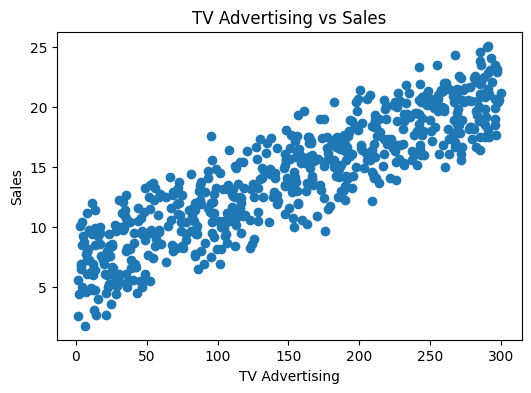

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.show()

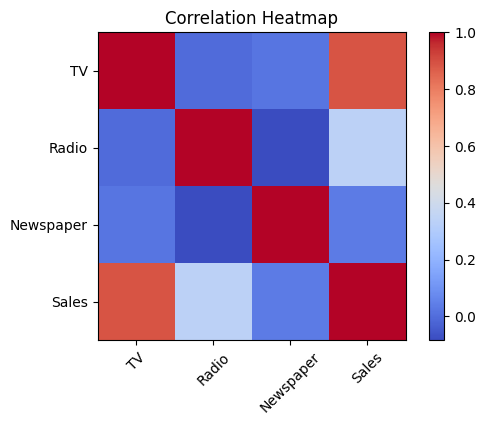

In [10]:
corr = df.corr()

plt.figure(figsize=(6,4))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

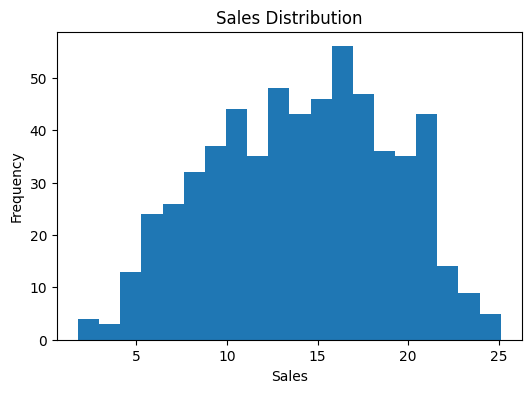

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df['Sales'], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [21]:
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
predictions = model.predict(X_test)
print(predictions)

[12.24073218 15.21097846 17.19049201  7.60667242  8.58638963 16.91156593
  4.25554514 19.89472867 14.55092305 16.64363697 18.0351033  17.31268101
  9.21324248  7.10918731  7.59254521  9.33662272 17.26672318 13.91880023
  8.76953806 17.59399693 15.22668165  6.15973449 18.40909258 19.56349528
 10.11902379  9.13272799  4.54559257 13.87759685  7.03601809 19.90759602
 15.62292546 16.18594315  9.69667753 16.95475437 19.77231256 21.74877271
  9.29908917  7.99798233 23.2523198  12.20523805 19.57589315  5.88480417
 19.63455573 14.97076715 14.10002896 19.22819588 17.21179417 17.65679615
 10.39912277 15.84019425 19.64039816 21.27484401 13.77040775 14.41868829
 16.84857959  7.33799277  7.09486705 19.16937109 19.11255767 14.36153663
 15.58013093 15.25907718  8.9804605  21.30699563 16.69131087 16.31272156
  7.92937312 10.24290647 14.62871229 11.65014316 16.86935012  5.99231136
 17.18909278  4.79218076 10.39212406 10.13143837  8.21586465 16.48942506
 13.10588576 14.35971197 14.42658587 15.17699126 10

In [27]:
print("R² Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R² Score: 0.9083296899137323
MAE: 1.2842648624492023


In [29]:
print(model.coef_)

[0.04900668 0.11933634 0.00768093]


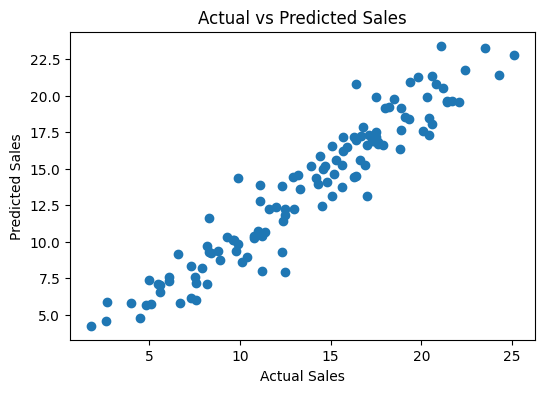

In [28]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [30]:
new_data = [[250, 35, 60]]

predicted_sales = model.predict(new_data)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 20.275120639901807


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
